In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Defining transformations with augmentation
transform = transforms.Compose([
    transforms.Resize((64, 64)),  # Resizing images to 64x64 pixels
    transforms.Grayscale(num_output_channels=1),  # Converts to grayscale
    transforms.RandomRotation(5),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),  # Converts images to PyTorch tensors
    transforms.Normalize((0.5,), (0.5,))
])


In [5]:
# Loading the dataset
dataset = datasets.ImageFolder(root='/content/dataset/cnn_dataset', transform=transform)

# Spliting the dataset into train, validation, and test sets
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, val_size, test_size])

# Loading datasets into DataLoader with batch size 64
train_data_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_data_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)
test_data_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)


In [6]:
class VGG13_MODL(nn.Module):
    def __init__(self, num_classes=36):
        super(VGG13_MODL, self).__init__()

        # Defining the feature extraction layers based on VGG13 structure
        self.features = nn.Sequential(
            # First convolutional block
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),  # Add batch normalization
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # Downsampling
            # Second convolutional block
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Third convolutional block
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Fourth convolutional block
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Fifth convolutional block
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # Defines the classifier layers
        self.classifier = nn.Sequential(
            nn.Linear(512 * 2 * 2, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),  # Dropout for regularization
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Moving the device to GPU
model = VGG13_MODL(num_classes=36).to(device)

# Defining loss, optimizer, and learning rate scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)


In [8]:
import time

# Training function with validation evaluation and timing
numb_epochs = 20
train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []
best_val_accuracy = 0

for epoch in range(numb_epochs):
    start_time = time.time()  # Starting time for the epoch

    # Training
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0

    for images, labels in train_data_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct_train += preds.eq(labels).sum().item()
        total_train += labels.size(0)
    avg_train_loss = running_loss / len(train_data_loader)
    train_accuracy = correct_train / total_train
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_accuracy)

    # Validation
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct_val += preds.eq(labels).sum().item()
            total_val += labels.size(0)
    avg_val_loss = val_loss / len(val_data_loader)
    val_accuracy = correct_val / total_val
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)

    # Scheduler and early stopping condition
    scheduler.step(avg_val_loss)

    end_time = time.time()  # End time for the epoch
    epoch_duration = end_time - start_time  # Duration for the epoch

    print(f"Epoch [{epoch+1}/{numb_epochs}], Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.4f}, "
          f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.4f}, Time: {epoch_duration:.2f} sec")

    # Saving the best model
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(model.state_dict(), 'sreedivy_meerahus_assignment2_part4.pt')


Epoch [1/20], Train Loss: 1.4290, Train Acc: 0.5201, Val Loss: 0.6277, Val Acc: 0.7768, Time: 112.09 sec
Epoch [2/20], Train Loss: 0.5986, Train Acc: 0.7953, Val Loss: 0.4860, Val Acc: 0.8263, Time: 111.37 sec
Epoch [3/20], Train Loss: 0.4761, Train Acc: 0.8358, Val Loss: 0.4157, Val Acc: 0.8420, Time: 113.00 sec
Epoch [4/20], Train Loss: 0.4156, Train Acc: 0.8569, Val Loss: 0.3414, Val Acc: 0.8818, Time: 111.37 sec
Epoch [5/20], Train Loss: 0.3841, Train Acc: 0.8676, Val Loss: 0.3686, Val Acc: 0.8683, Time: 112.82 sec
Epoch [6/20], Train Loss: 0.3565, Train Acc: 0.8766, Val Loss: 0.3533, Val Acc: 0.8770, Time: 113.26 sec
Epoch [7/20], Train Loss: 0.3341, Train Acc: 0.8844, Val Loss: 0.3271, Val Acc: 0.8860, Time: 111.96 sec
Epoch [8/20], Train Loss: 0.3165, Train Acc: 0.8892, Val Loss: 0.3252, Val Acc: 0.8876, Time: 111.62 sec
Epoch [9/20], Train Loss: 0.3027, Train Acc: 0.8935, Val Loss: 0.3163, Val Acc: 0.8864, Time: 112.39 sec
Epoch [10/20], Train Loss: 0.2896, Train Acc: 0.8965, V

In [14]:
# Loading best model and test
model.load_state_dict(torch.load('sreedivy_meerahus_assignment2_part4.pt'))
model.eval()
correct_test, total_test = 0, 0

with torch.no_grad():
    for images, labels in test_data_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        correct_test += preds.eq(labels).sum().item()
        total_test += labels.size(0)

test_accuracy = correct_test / total_test
print(f'Test Accuracy: {test_accuracy:.4f}')


<ipython-input-14-f419d5ead01f>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('sreedivy_meerahus_assignment2_part4.pt'))


Test Accuracy: 0.9129


Test Accuracy: 0.9101, Precision: 0.9128, Recall: 0.9111, F1 Score: 0.9105


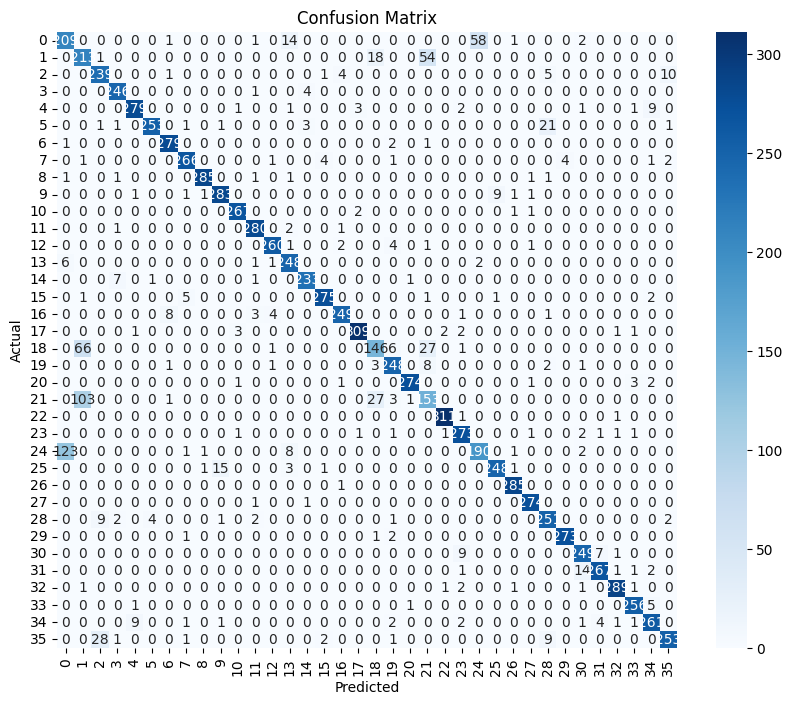

In [19]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix,roc_curve,auc
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Placeholders to store predictions and labels
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_data_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())  # Moves predictions from GPU to CPU
        all_labels.extend(labels.cpu().numpy())  ## Moves labels from GPU to CPU

# Convert lists to numpy arrays for metric calculation
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Calculate accuracy, precision, recall, and F1-score
test_accuracy = np.mean(all_preds == all_labels)
precision = precision_score(all_labels, all_preds, average='macro')
recall = recall_score(all_labels, all_preds, average='macro')
f1 = f1_score(all_labels, all_preds, average='macro')

print(f'Test Accuracy: {test_accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}')

# Displays confusion matrix
conf_matrix = confusion_matrix(all_labels, all_preds)

# Plotting the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(36), yticklabels=range(36))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


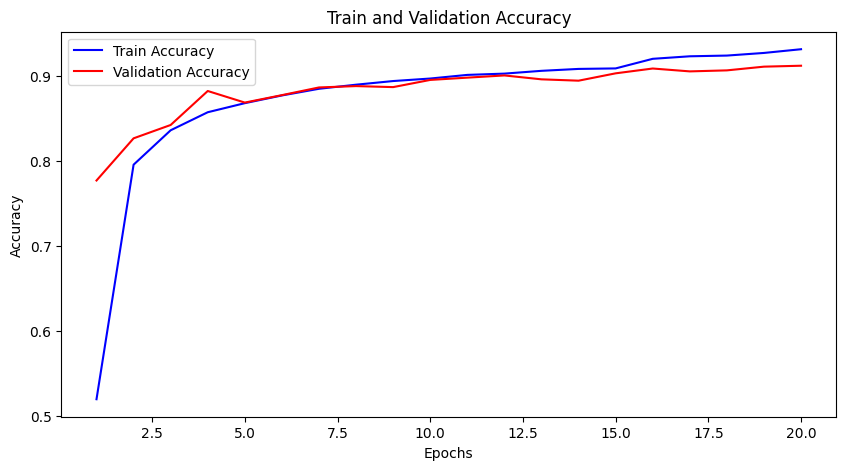

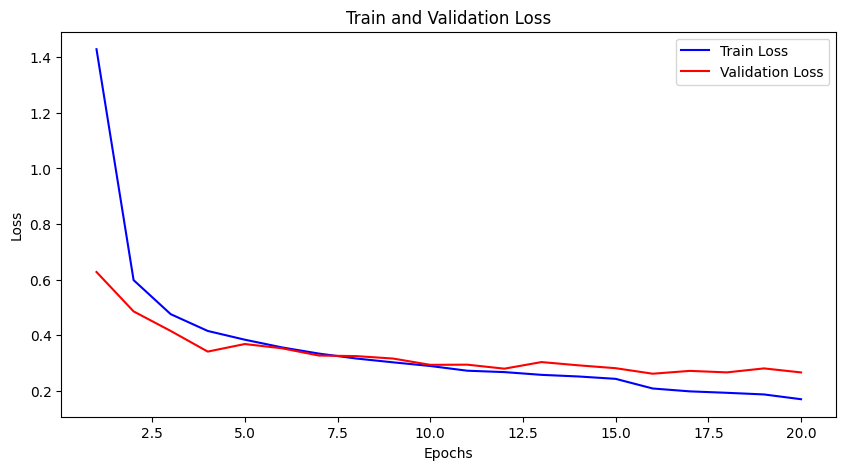

In [20]:
# Plotting function for accuracy and loss curves
def plot_curves(train_accuracies, val_accuracies, train_losses, val_losses):
    epochs = range(1, len(train_accuracies) + 1)

    # Accuracy curve
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, train_accuracies, 'b', label='Train Accuracy')
    plt.plot(epochs, val_accuracies, 'r', label='Validation Accuracy')
    plt.title('Train and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    # Loss curve
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, train_losses, 'b', label='Train Loss')
    plt.plot(epochs, val_losses, 'r', label='Validation Loss')
    plt.title('Train and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()
# After the training loop ends, plot accuracy and loss curves
plot_curves(train_accuracies, val_accuracies, train_losses, val_losses)


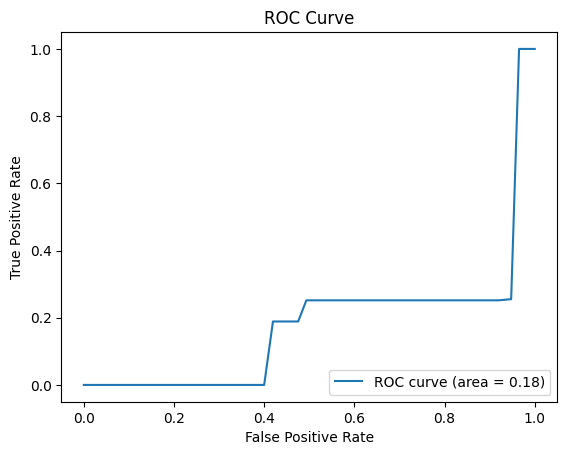

In [21]:
#Plotting ROC Curve
fpr, tpr, _ = roc_curve(all_labels, all_preds, pos_label=1)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

In [12]:
'Reference: https://arxiv.org/abs/1409.1556,https://lightning.ai/docs/torchmetrics/stable/classification/roc.html,https://lightning.ai/docs/torchmetrics/stable/classification/roc.html,https://seaborn.pydata.org/generated/seaborn.heatmap.html'

'Reference: https://arxiv.org/abs/1409.1556,https://lightning.ai/docs/torchmetrics/stable/classification/roc.html,https://lightning.ai/docs/torchmetrics/stable/classification/roc.html,https://seaborn.pydata.org/generated/seaborn.heatmap.html'